In [ ]:
import marimo as mo
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier

# **The Dead Salmons of AI Interpretability**

In 2009, researcher Craig Bennett placed a dead Atlantic salmon in an fMRI machine and showed it pictures of humans in social situations. When analyzing the data *without correcting for multiple comparisons*, the fMRI detected "brain activity" in the dead fish.

If your math lacks sanity checks, it will hallucinate intelligence out of pure noise.

> **Your Challenge, Judge:** Tweak the parameters below to force our untrained, "dead fish" AI to show statistically significant intelligence.

In [ ]:
sample_size = mo.ui.slider(start=100, stop=5000, step=1, value=100, label="Data Sample Size (N)")
feature_count = mo.ui.slider(start=100, stop=5000, step=1, value=100, label="Feature Count (Dimensions)")
method = mo.ui.dropdown(
    options=["Feature Importance (Random Forest)", "Saliency Mapping (Dummy Tensor)"],
    value= "Feature Importance (Random Forest)",
    label="Interpretability Method",
)
p_thresh = mo.ui.number(start=0.001, stop=0.5, step=0.001, value=0.01, label="Significance Threshold (p-value)")

title = mo.hstack(items=[mo.md("### Researcher's Control Panel")], align="center")
controls_1 = mo.hstack(
    items = [sample_size, feature_count],
    align="center"
    )
controls_2 = mo.hstack(
    items=[method, p_thresh],
    align="center"
    )
control_panel = mo.vstack(
    items=[title, controls_1, controls_2],
    align="center",
    gap=0.5,
    heights=[1, 1, 1],
).style(padding="1rem", border="1px solid #00FFFF", border_radius="8px")

In [ ]:
# 1. To Generate Pure Noise
N = sample_size.value
m = feature_count.value
alpha = p_thresh.value

Y = np.random.randn(N)
X = np.random.randn(N, m)

# 2. Hunting down the Fluke!
correlations = []
p_values = []

for i in range(m):
    r, p = stats.pearsonr(X[:, i], Y)
    correlations.append(abs(r))
    p_values.append(p)

# 3. Singling out the best of False Positives
best_idx = np.argmin(p_values if p_values else [0])
best_p_val = p_values[best_idx]

# Identifying the top 10 features to making a good dashboard
top_10_indices = np.argsort(p_values)[:10]
top_10_p_vals = [p_values[i] for i in top_10_indices]

# Normalizing the correlations for the chart display (0-1)
max_corr = max(correlations)
important_scores = [correlations[i]/max_corr for i in top_10_indices]

# Checking if the trap is sprung
trap_sprung = best_p_val < alpha

In [ ]:
# 1. Generating stable 3D coordinates for the 'brain/tensor' structure
# We use static seed so the cloud shape doesn't violently jump around when tweaking sliders
np.random.seed(42)
# Morphing the 3D shape based on the Interpretability Method
if "Random Forest" in method.value:
    # Organic Sphercal Brain Cloud Shape (Gaussian Distribution)
    x_coords = np.random.randn(m)
    y_coords = np.random.randn(m)
    z_coords = np.random.randn(m)
else:
    # Rigid uniform tensor cube (Uniform Distribution)
    # Scaled from -3 to 3 to roughly match the visual volume of the Gaussian Cloud
    x_coords = np.random.uniform(-3, 3, m)
    y_coords = np.random.uniform(-3, 3, m)
    z_coords = np.random.uniform(-3, 3, m)

# 2. Color & Size Logic
marker_sizes = [24 if p < alpha else 12 for p in p_values]
marker_colors = ['rgba(255, 105, 38, 1)' if p < alpha else 'rgba(166, 68, 68, 0.2)' for p in p_values]

# 3. Building the WebGL Scatter Plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    mode='markers',
    marker=dict(
        size=marker_sizes,
        color=marker_colors,
        line=dict(width=0),
    ),
    text=[f"Feature {i} | p-value: {p:.4f}" for i, p in enumerate(p_values)],
    hoverinfo="text",
)])

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor='rgba(0, 0, 0, 0)',
    margin=dict(l=0, r=0, b=0, t=30),
    # title=dict(text="3D Feature Activation Cloud", font=dict(color="black")),
    scene=dict(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title='', showbackground=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title='', showbackground=False),
        zaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title='', showbackground=False),
        bgcolor='rgba(120, 120, 120, 10)'
    )
)

chart = mo.ui.plotly(fig)

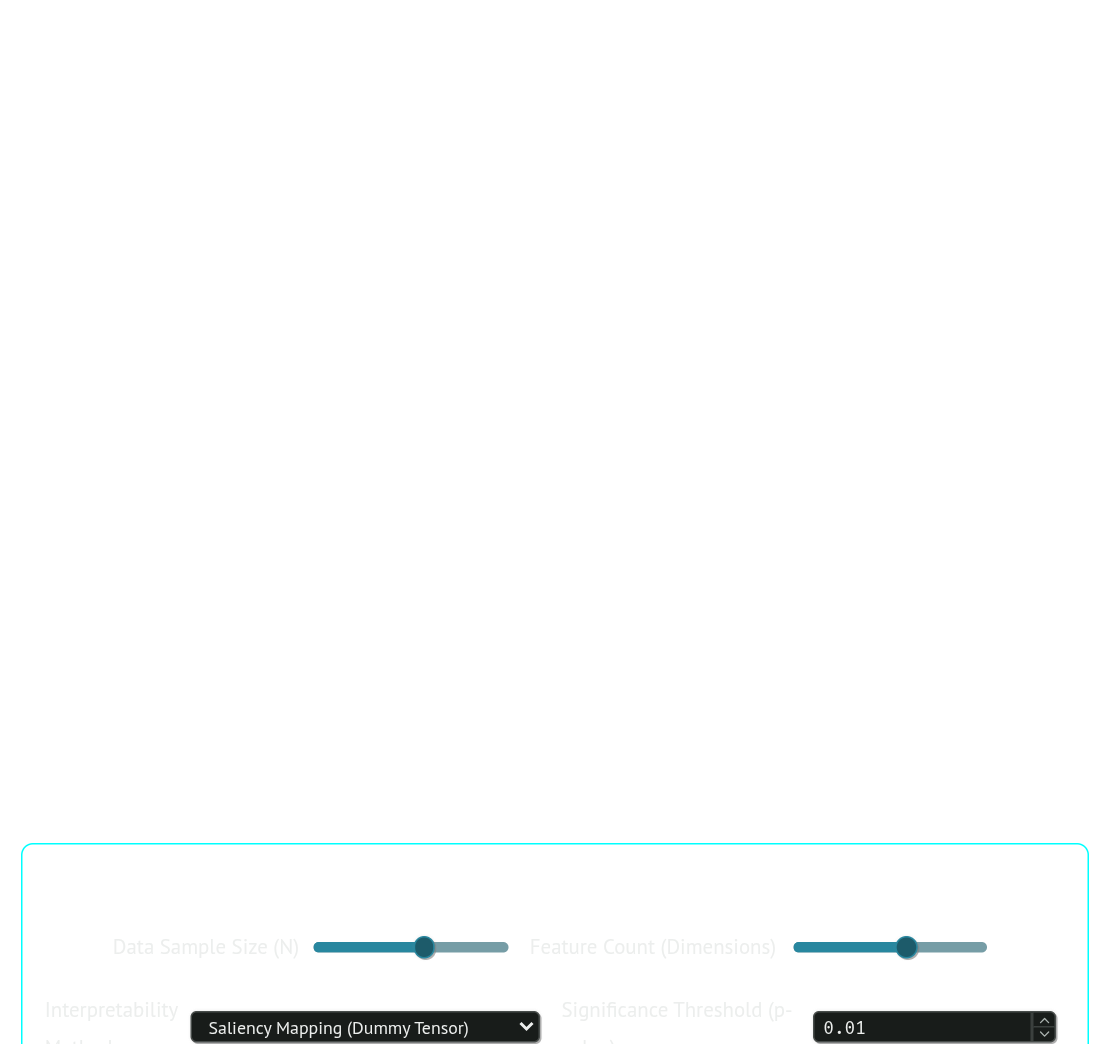

In [ ]:
# Combining Controls & the Chart into two columns
dashboard = mo.vstack(
    [chart, control_panel],
)
dashboard

In [ ]:
if trap_sprung:
    status = mo.md(f"### ✅ **TRAP SPRUNG: Statistical Illusion Achieved!** You forced a false positive out of pure noise. (Lowest p-value: {best_p_val:.4f})")
    status = status.style(color="#00FF00", background_color="#1a331a", padding="1rem", border_radius="8px")
else:
    status = mo.md(f"### ❌ **STATUS: NO SIGNAL DETECTED.** The model is behaving like a dead fish. (Lowest p-value: {best_p_val:.4f})")
    status = status.style(color="#FF4444", background_color="#331a1a", padding="1rem", border_radius="8px")

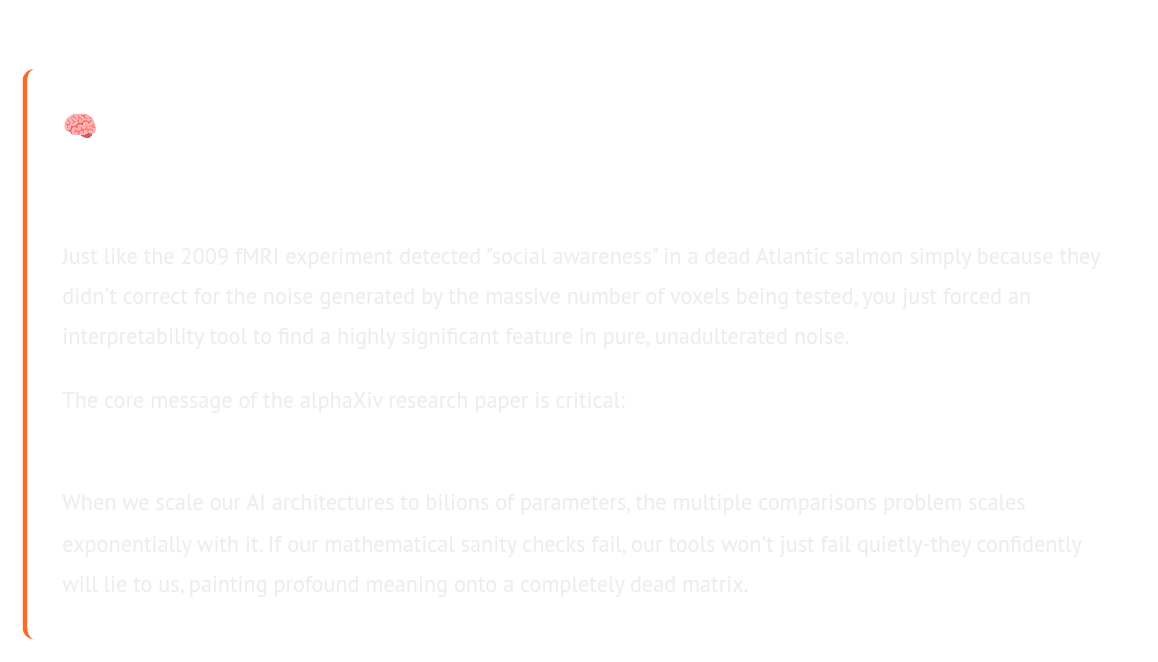

In [ ]:
if not trap_sprung:
    content = """
    ### 🔬 The Experiment is Ongoing!
    The neural matrix is currently stable, so adjust the features and significance thresholds in the control panel to see if you can force the interpretability tools to hallucinate a false positive.
    """
    border_color = "#00FFFF" # Calm Cyan, isn't too harsh on the eyes
else:
    content="""
    ### 🧠 Post-Mortem: The alphaXiv Connection
    **You just replicated the Dead Salmon Effect in AI.**

    Just like the 2009 fMRI experiment detected "social awareness" in a dead Atlantic salmon simply because they didn't correct for the noise generated by the massive number of voxels being tested, you just forced an interpretability tool to find a highly significant feature in pure, unadulterated noise.

    The core message of the alphaXiv research paper is critical: **Interpretability tools applied to untrained / highly noisy networks can still produce highly convincing, human-readable explanations.**

    When we scale our AI architectures to bilions of parameters, the multiple comparisons problem scales exponentially with it. If our mathematical sanity checks fail, our tools won't just fail quietly-they confidently will lie to us, painting profound meaning onto a completely dead matrix. 
    """
    border_color = "#FF6926" # Burnt orange to match the hallucinated node

# Wrapping it in a sleek, semi-transparent card with a dynamic left border
ui_card = mo.md(content).style(
    padding="1.5rem",
    border_radius="8px",
    background_color="rgba(255, 255, 255, 0.03)",
    border_left=f"4px solid {border_color}",
    margin_top="2rem",
)
ui_card